# 05 · Draft

We draft the ten players that give us the most expected points, within the seed caps, while nine other teams pick in snake order.

**Main assumption:** opponents draft by seed with some individual judgement (each ranks players by seed × a random factor of about ±35%). There are ten teams. Section 7 compares two other assumptions, for discussion only.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.pipeline import build
from src.simulator import ShotModel, league_course
from src.lineup import role_shot_counts, role_values, outcome_curve, fixture_from_edges
from src.draft import (Pool, Draft, CAPS, snake_order, opponent_prefs, run_draft, pick_lookahead,
                       league_table, draft_positions, lineup_pair_edges)
from src.viz import set_style, PALETTE, NEUTRAL, INK_2

set_style()
pd.set_option("display.width", 200)

P = build()
ratings = P["ratings"]
model = ShotModel.build(P["shots"], ratings)
course = league_course(P["course_holes"], P["shots"])
values = role_values(model, role_shot_counts(model, course), ratings.index)
pool = Pool.from_values(values, ratings)
curve = outcome_curve(model, course, edges=np.arange(-2.5, 2.51, 0.25), n=8000)
OPP = "B"   # main assumption

## Where players usually go

We simulate many drafts under this assumption and record each player's average pick.

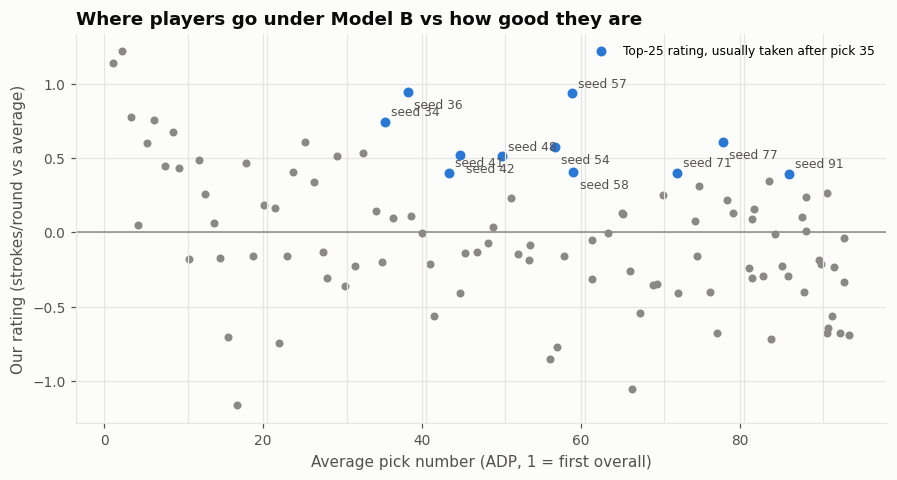

,seed,rating,ADP,undrafted %,rating rank,value gap
a9a26d8ab8,77,0.61,77.88,3.00,9,68.88
c2b49b6d5d,99,0.26,90.93,29.00,29,61.93
a24a0a41a6,91,0.39,86.25,12.00,25,61.25
652948de3e,86,0.35,83.70,7.00,26,57.69
2650e6ae09,92,0.24,88.40,18.00,32,56.40
4a245c5a52,57,0.94,58.82,0.00,4,54.82
59bc4fb041,71,0.40,72.07,0.50,23,49.07
98d3bb7def,74,0.31,74.90,1.25,28,46.90
31f2c969ee,83,0.15,81.85,6.25,37,44.85
2c5ae1578e,90,0.10,87.83,16.25,43,44.83


In [2]:
adp = draft_positions(pool, OPP, n=400, seed=1)
avg_pick = adp.replace(np.inf, 101).mean()
board = pd.DataFrame({"seed": pool.seed, "rating": pool.rating * 2, "ADP": avg_pick.values,
                      "undrafted %": (adp == np.inf).mean().values * 100}, index=pool.ids)
board["rating rank"] = board.rating.rank(ascending=False).astype(int)
board["value gap"] = board.ADP - board["rating rank"] * 1.0   # picks later than her quality warrants

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.scatter(board.ADP, board.rating, s=18, color=NEUTRAL)
sleepers = board[(board["rating rank"] <= 25) & (board.ADP >= 35)]
ax.scatter(sleepers.ADP, sleepers.rating, s=30, color=PALETTE[0], label="Top-25 rating, usually taken after pick 35")
for j, (pid, r) in enumerate(sleepers.sort_values("ADP").iterrows()):
    ax.annotate(f"seed {int(r.seed)}", (r.ADP, r.rating), xytext=(4, 4 if j % 2 == 0 else -11),
                textcoords="offset points", fontsize=8, color=INK_2)
for x in range(10, 100, 10):
    ax.axvline(x + 0.5, color="#e6e5e1", lw=0.8)
ax.axhline(0, color=NEUTRAL, lw=1)
ax.set(title="Where players go under Model B vs how good they are", xlabel="Average pick number (ADP, 1 = first overall)",
       ylabel="Our rating (strokes/round vs average)")
ax.legend(loc="upper right", fontsize=8)
plt.show()
board.sort_values("value gap", ascending=False).head(10).round(2)

Several top-25 players usually go after pick 35. That is the opportunity: take them late, and spend early picks on players who will not last.

## Three ways to draft

Seed: take the best seed, like everyone else. Greedy: take the best player by our rating. Lookahead: for a few candidates, simulate the rest of the draft 24 times and take the one with the best expected final roster. It checks the caps every pick.

## One draft, pick by pick

From slot 5, with the options the engine weighed at each pick.

In [3]:
SLOT = 4  # 0-based: fifth pick in round 1
d, hist = run_draft(pool, SLOT, "lookahead", OPP, seed=2024, log=True)
ours = hist[hist.ours].copy()
id2idx = {pid: i for i, pid in enumerate(pool.ids)}
def alternatives(scores):
    top = sorted(scores.items(), key=lambda kv: -kv[1])[:3]
    return " · ".join(f"seed {pool.seed[i]} ({v:.2f})" for i, v in top)
ours["alternatives (expected final value)"] = ours.scores.apply(alternatives)
ours["rating rank"] = ours.player.map(board["rating rank"])
ours[["round", "pick", "seed", "rating rank", "alternatives (expected final value)"]]

,round,pick,seed,rating rank,alternatives (expected final value)
4,1,5,6,6,seed 6 (3.08) · seed 8 (3.03) · seed 5 (3.00)
15,2,16,34,7,seed 34 (3.11) · seed 24 (3.09) · seed 36 (3.07)
24,3,25,36,3,seed 36 (3.08) · seed 24 (3.05) · seed 42 (3.04)
35,4,36,57,4,seed 57 (3.11) · seed 54 (3.09) · seed 48 (3.07)
44,5,45,54,12,seed 54 (3.08) · seed 77 (3.06) · seed 58 (3.04)
55,6,56,77,9,seed 77 (3.11) · seed 58 (3.09) · seed 74 (3.07)
64,7,65,58,22,seed 58 (3.11) · seed 74 (3.10) · seed 86 (3.09)
75,8,76,86,26,seed 86 (3.14) · seed 91 (3.13) · seed 74 (3.13)
84,9,85,91,25,seed 91 (3.17) · seed 74 (3.17) · seed 78 (3.17)
95,10,96,92,32,seed 92 (3.15) · seed 103 (3.04) · seed 95 (2.95)


In [4]:
lt = league_table(pool, d.rosters, curve)
lt["seeds"] = [sorted(pool.seed[r].tolist()) for r in d.rosters]
lt["ours"] = np.where(lt.index == SLOT + 1, "◀ us", "")
lt.sort_values("exp_points", ascending=False).round(2)

,lineup_value,exp_points,win_pct,draw_pct,seeds,ours
team,,,,,,
5,3.15,2.79,53.96,14.08,"[6, 34, 36, 54, 57, 58, 77, 86, 91, 92]",◀ us
1,1.31,2.61,46.83,14.51,"[1, 13, 31, 32, 48, 71, 73, 84, 85, 94]",
2,0.48,2.52,43.50,14.58,"[2, 14, 28, 41, 51, 55, 62, 80, 88, 102]",
6,0.14,2.49,42.32,14.57,"[5, 12, 25, 47, 49, 50, 59, 65, 98, 99]",
7,0.04,2.48,41.89,14.57,"[8, 11, 24, 26, 39, 56, 63, 72, 87, 105]",
8,-0.07,2.47,41.49,14.57,"[9, 18, 23, 35, 38, 43, 52, 76, 89, 90]",
9,-0.17,2.46,41.14,14.56,"[7, 16, 21, 37, 42, 45, 70, 74, 79, 93]",
10,-0.57,2.42,39.73,14.53,"[10, 15, 20, 27, 61, 66, 69, 75, 78, 82]",
4,-0.61,2.42,39.63,14.53,"[4, 17, 30, 33, 40, 44, 64, 83, 96, 101]",


Early on it takes top seeds, because it expects the undervalued players to still be there next round. Later it collects them. 

## Every draft slot

In [5]:
rows = []
for slot in range(10):
    for rep in range(8):
        for pol in ["seed", "greedy", "lookahead"]:
            dd, _ = run_draft(pool, slot, pol, OPP, seed=10_000 + 100 * slot + rep)
            lt_ = league_table(pool, dd.rosters, curve)
            rows.append({"slot": slot + 1, "rep": rep, "policy": pol,
                         "roster value": lt_.lineup_value.iloc[slot],
                         "others' average": lt_.lineup_value.drop(slot + 1).mean(),
                         "exp points": lt_.exp_points.iloc[slot], "win %": lt_.win_pct.iloc[slot],
                         "league rank": int((lt_.exp_points > lt_.exp_points.iloc[slot]).sum() + 1)})
res = pd.DataFrame(rows)
by_pol = res.groupby("policy")[["roster value", "others' average", "exp points", "win %", "league rank"]].mean()
by_pol.loc[["seed", "greedy", "lookahead"]].round(2)

,roster value,others' average,exp points,win %,league rank
policy,,,,,
seed,0.51,0.28,2.53,43.67,4.58
greedy,2.99,0.02,2.77,53.32,1.00
lookahead,3.16,0.00,2.79,53.90,1.00


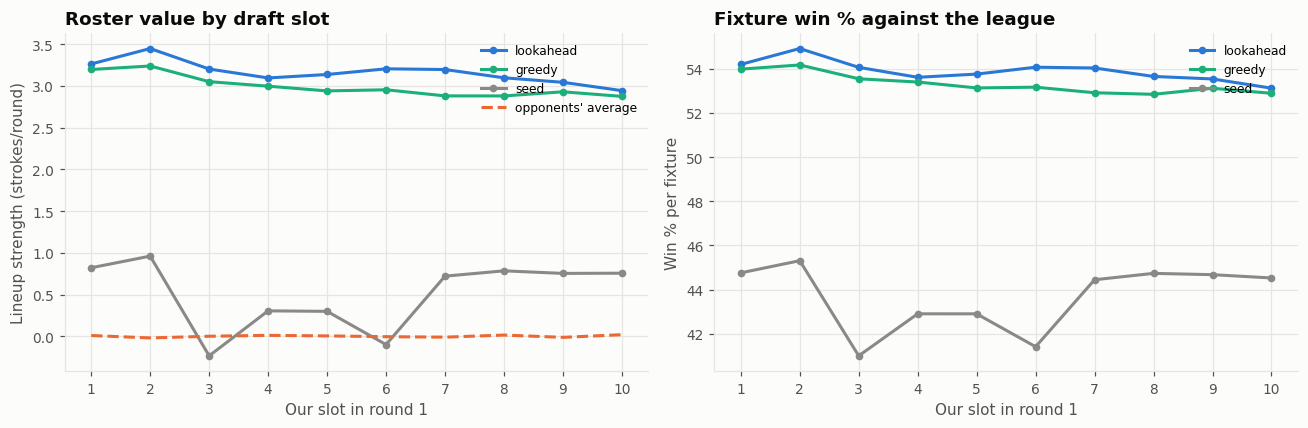

Lookahead minus greedy: +0.169 strokes/round (standard error 0.017)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for pol, col in zip(["lookahead", "greedy", "seed"], [PALETTE[0], PALETTE[2], NEUTRAL]):
    g = res[res.policy == pol].groupby("slot")
    axes[0].plot(g["roster value"].mean().index, g["roster value"].mean(), marker="o", ms=4, color=col, label=pol)
    axes[1].plot(g["win %"].mean().index, g["win %"].mean(), marker="o", ms=4, color=col, label=pol)
axes[0].plot(range(1, 11), res[res.policy == "lookahead"].groupby("slot")["others' average"].mean(), color=PALETTE[1], ls="--", label="opponents' average")
axes[0].set(title="Roster value by draft slot", xlabel="Our slot in round 1", ylabel="Lineup strength (strokes/round)")
axes[1].set(title="Fixture win % against the league", xlabel="Our slot in round 1", ylabel="Win % per fixture")
axes[0].legend(loc="upper right", fontsize=8); axes[1].legend(loc="upper right", fontsize=8)
for ax in axes:
    ax.set_xticks(range(1, 11))
plt.tight_layout(); plt.show()

w = res.pivot_table(index=["slot", "rep"], columns="policy", values="roster value")
diff = w.lookahead - w.greedy
print(f"Lookahead minus greedy: {diff.mean():+.3f} strokes/round (standard error {diff.std() / np.sqrt(len(diff)):.3f})")

Drafting by seed gives an average team. Our ratings add about 3 strokes per round of lineup strength. Lookahead adds a little more, and wins the league from every slot: 2.79 expected points per fixture against 2.53, and a 54% win rate against 44%. 

In [7]:
freq = {}
n_drafts = 0
for slot in range(10):
    for rep in range(3):
        dd, _ = run_draft(pool, slot, "lookahead", OPP, seed=50_000 + 100 * slot + rep)
        n_drafts += 1
        for p in dd.rosters[slot]:
            freq[pool.ids[p]] = freq.get(pool.ids[p], 0) + 1
targets = pd.Series(freq, name="share of our drafts").div(n_drafts).sort_values(ascending=False)
targets.to_frame().join(board[["seed", "rating", "rating rank", "ADP"]]).head(15).round(2)

,share of our drafts,seed,rating,rating rank,ADP
8399e3fca3,0.97,34,0.75,7,35.31
3026b3a2ae,0.87,36,0.95,3,38.26
a9a26d8ab8,0.83,77,0.61,9,77.88
4a245c5a52,0.83,57,0.94,4,58.82
9970383dd6,0.67,42,0.52,14,44.82
b429ef3b9c,0.53,54,0.58,12,56.79
652948de3e,0.53,86,0.35,26,83.70
a24a0a41a6,0.50,91,0.39,25,86.25
59bc4fb041,0.47,71,0.40,23,72.07
b54e523ca9,0.43,78,0.22,34,78.44


## If a target is taken

We replay a draft in which an opponent takes our favourite target just before us.

In [8]:
top_target = id2idx[targets.index[0]]
d1, h1 = run_draft(pool, SLOT, "lookahead", OPP, seed=77, log=True)
first_pick_round = h1[(h1.ours) & (h1.player == pool.ids[top_target])]

class Sniped(Exception):
    pass

def run_with_snipe(snipe_idx, seed=77):
    rng = np.random.default_rng(seed)
    dd = Draft(pool)
    prefs = opponent_prefs(pool, OPP, 10, rng)
    # the opponent picking just before our first pick of the target takes her instead
    target_pick = int(first_pick_round.pick.iloc[0]) if len(first_pick_round) else None
    log = []
    while not dd.done:
        t = dd.on_clock
        if t == SLOT:
            p = pick_lookahead(dd, t, rng, opp_model=OPP)
        elif target_pick is not None and dd.pick_no + 2 == target_pick and dd.available[snipe_idx] and dd.feasible(t, snipe_idx):
            p = snipe_idx
        else:
            p = dd.first_feasible(t, prefs[t])
        log.append({"pick": dd.pick_no + 1, "team": t + 1, "seed": int(pool.seed[p]), "ours": t == SLOT, "player": pool.ids[p]})
        dd.take(t, p)
    return dd, pd.DataFrame(log)

if len(first_pick_round):
    d2, h2 = run_with_snipe(top_target)
    cmp = pd.DataFrame({"normal draft: our seeds": sorted(pool.seed[d1.rosters[SLOT]]),
                        "target sniped: our seeds": sorted(pool.seed[d2.rosters[SLOT]])})
    print(f"Target: seed {pool.seed[top_target]} (rating rank {board.loc[pool.ids[top_target], 'rating rank']}), "
          f"sniped at pick {int(first_pick_round.pick.iloc[0]) - 1}")
    print(f"Roster value: normal {pool.roster_value(d1.rosters[SLOT]):.2f} · after snipe {pool.roster_value(d2.rosters[SLOT]):.2f}")
    display(cmp)
else:
    print("In this replay the engine did not take the top target, so no snipe is needed.")

Target: seed 34 (rating rank 7), sniped at pick 15
Roster value: normal 3.25 · after snipe 3.20


,normal draft: our seeds,target sniped: our seeds
0,6,6
1,34,24
2,36,36
3,42,42
4,54,54
5,57,57
6,77,77
7,78,78
8,91,91
9,99,99


The engine re-plans and loses almost nothing. It is a strategy, not a fixed list. Next: what if opponents are smarter?

## Other assumptions (for discussion)

A: opponents follow the seed exactly. C: opponents use ratings as good as ours:>

In [9]:
rows = []
for m in ["A", "B", "C"]:
    for slot in [0, 4, 9]:
        for rep in range(4):
            for pol in ["greedy", "lookahead"]:
                dd, _ = run_draft(pool, slot, pol, m, seed=90_000 + 100 * slot + rep)
                lt_ = league_table(pool, dd.rosters, curve)
                rows.append({"opponent model": m, "policy": pol, "roster value": lt_.lineup_value.iloc[slot],
                             "margin over opponents": lt_.lineup_value.iloc[slot] - lt_.lineup_value.drop(slot + 1).mean(),
                             "win %": lt_.win_pct.iloc[slot],
                             "league rank": int((lt_.exp_points > lt_.exp_points.iloc[slot]).sum() + 1)})
sens = pd.DataFrame(rows).groupby(["opponent model", "policy"]).mean(numeric_only=True)
sens.round(2)

roster value  margin over opponents  win %  league rank
opponent model policy                                                            
A              greedy             2.97                   2.93  53.23         1.00
               lookahead          3.18                   3.15  53.89         1.00
B              greedy             3.04                   3.04  53.55         1.00
               lookahead          3.14                   3.16  53.88         1.00
C              greedy             0.66                   0.24  43.52         1.92
               lookahead          0.78                   0.37  43.93         1.17

Strict-seed opponents change nothing. Opponents as sharp as us cut our edge by about 90%. So the edge comes mostly from rating players better than the seed does.

Limits: the opponent model is an assumption, ratings carry uncertainty, and role values come from one course. With more time: learn each opponent's habits from their early picks, and optimise the whole season.